# CS412 Machine Learning - Homework 1
**32417** Mustafa Bozyel

This notebook implements and evaluates **k-Nearest Neighbors (k-NN)** and **Decision Tree** classifiers on the **Breast Cancer Wisconsin Diagnostic** dataset.



## 1. Imports
We use scikit-learn for loading the dataset, splitting the data, preprocessing, model training, and evaluation.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Make plots appear inside the notebook
%matplotlib inline

# Optional style improvements for readability
plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25


## 2. Load Dataset
According to the homework, the dataset is loaded with `load_breast_cancer()` from scikit-learn.


In [2]:

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Convert to a DataFrame for easier analysis
df = pd.DataFrame(X, columns=data.feature_names)
df["target"] = y

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("Target names:", data.target_names)


Feature matrix shape: (569, 30)
Target vector shape: (569,)
Target names: ['malignant' 'benign']


## 3. Train / Validation / Test Split
The homework asks for:
- 70% training set
- Remaining 30% split equally into validation and test sets
- `random_state=42`


In [3]:

# First split: 70% training, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, train_size=0.7, random_state=42
)

# Second split: divide the remaining 30% equally into validation and test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print("Training set shape   :", X_train.shape, y_train.shape)
print("Validation set shape :", X_val.shape, y_val.shape)
print("Test set shape       :", X_test.shape, y_test.shape)


Training set shape   : (398, 30) (398,)
Validation set shape : (85, 30) (85,)
Test set shape       : (86, 30) (86,)


## 4. Data Analysis Before Preprocessing
We analyze the dataset before standardization, as requested.


In [4]:

# Class distribution in the full dataset
class_counts = pd.Series(y).value_counts().sort_index()
class_distribution = pd.DataFrame({
    "Class": data.target_names,
    "Count": class_counts.values
})

print("Class distribution:")
display(class_distribution)

malignant_count = class_counts.iloc[0]
benign_count = class_counts.iloc[1]

total_samples = len(y)
malignant_ratio = malignant_count / total_samples
benign_ratio = benign_count / total_samples

print(f"Malignant ratio: {malignant_ratio:.3f}")
print(f"Benign ratio   : {benign_ratio:.3f}")

if abs(malignant_ratio - benign_ratio) < 0.05:
    print("Interpretation: The dataset is approximately balanced.")
else:
    print("Interpretation: The dataset is somewhat skewed toward the benign class.")


Class distribution:


,Class,Count
0,malignant,212
1,benign,357


Malignant ratio: 0.373
Benign ratio   : 0.627
Interpretation: The dataset is somewhat skewed toward the benign class.


In [5]:

# Mean and standard deviation for the first three requested features
selected_features = ["mean radius", "mean texture", "mean perimeter"]

basic_stats = pd.DataFrame({
    "Mean": df[selected_features].mean(),
    "Standard Deviation": df[selected_features].std()
})

print("Basic statistics for the first three features:")
display(basic_stats)


Basic statistics for the first three features:


,Mean,Standard Deviation
mean radius,14.127292,3.524049
mean texture,19.289649,4.301036
mean perimeter,91.969033,24.298981


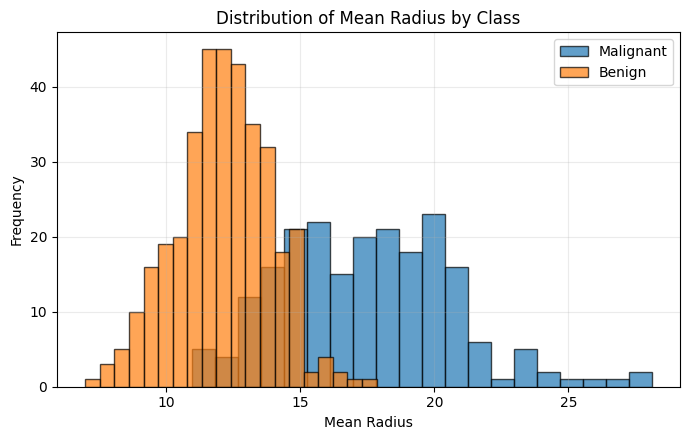

In [4]:

# Plot histogram of mean radius for each class
plt.figure(figsize=(7, 4.5))

plt.hist(
    df[df["target"] == 0]["mean radius"],
    bins=20,
    alpha=0.7,
    label="Malignant",
    edgecolor="black"
)

plt.hist(
    df[df["target"] == 1]["mean radius"],
    bins=20,
    alpha=0.7,
    label="Benign",
    edgecolor="black"
)

plt.title("Distribution of Mean Radius by Class")
plt.xlabel("Mean Radius")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()

# Save figure for the PDF report as well
plt.savefig("mean_radius_hist.png", dpi=200)
plt.show()


## 5. Data Preprocessing
Since k-NN relies on distances, standardization is important so that large-scale features do not dominate the distance calculation.

We fit the scaler **only on the training set** and then apply the same transformation to validation and test sets.


In [5]:

# Standardize features using only the training set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Training set mean after scaling (first 5 features):")
print(np.round(X_train_scaled.mean(axis=0)[:5], 4))

print("\nTraining set std after scaling (first 5 features):")
print(np.round(X_train_scaled.std(axis=0)[:5], 4))


Training set mean after scaling (first 5 features):
[-0. -0. -0.  0. -0.]

Training set std after scaling (first 5 features):
[1. 1. 1. 1. 1.]


**Why fit the scaler only on the training set?**

If we fit the scaler on all data, information from the validation and test sets would leak into training through the normalization parameters. That would make the evaluation unfair because the model would indirectly use information from unseen data. Fitting on the training set only prevents data leakage and gives a realistic estimate of generalization performance.


## 6. k-NN Classifier
Based on the lecture idea, k-NN predicts the label of a test point using the labels of its nearest neighbors. We select the best `k` using validation accuracy.


In [12]:

# Candidate k values given in the homework
k_values = [1, 3, 5, 7, 9, 15, 21]
knn_val_accuracies = []

for k in k_values:
    # Initialize and train the k-NN classifier
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train_scaled, y_train)

    # Evaluate on the validation set
    y_val_pred = knn_model.predict(X_val_scaled)
    val_acc = accuracy_score(y_val, y_val_pred)
    knn_val_accuracies.append(val_acc)

    print(f"k = {k:2d} -> validation accuracy = {val_acc:.4f}")

# Create a small summary table
knn_results_df = pd.DataFrame({
    "k": k_values,
    "Validation Accuracy": knn_val_accuracies
})

display(knn_results_df)


k =  1 -> validation accuracy = 0.9176
k =  3 -> validation accuracy = 0.9294
k =  5 -> validation accuracy = 0.9294
k =  7 -> validation accuracy = 0.9294
k =  9 -> validation accuracy = 0.9529
k = 15 -> validation accuracy = 0.9529
k = 21 -> validation accuracy = 0.9529


,k,Validation Accuracy
0,1,0.917647
1,3,0.929412
2,5,0.929412
3,7,0.929412
4,9,0.952941
5,15,0.952941
6,21,0.952941


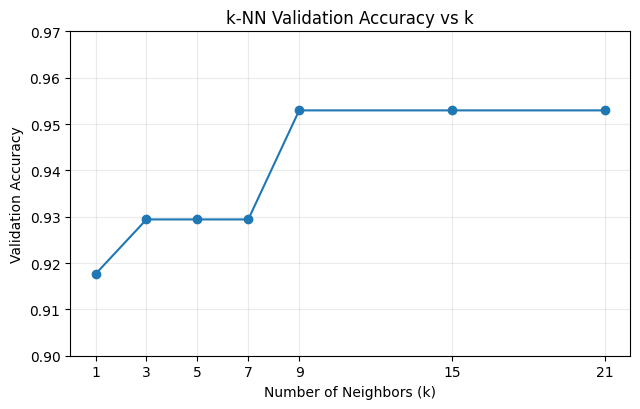

In [11]:

# Plot validation accuracy vs. k
plt.figure(figsize=(6.5, 4.2))
plt.plot(k_values, knn_val_accuracies, marker="o")
plt.title("k-NN Validation Accuracy vs k")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Validation Accuracy")
plt.xticks(k_values)
plt.ylim(0.90, 0.97)
plt.tight_layout()

plt.savefig("knn_validation_accuracy.png", dpi=200)
plt.show()


In [7]:

# Select the smallest k among the best validation accuracies
best_knn_accuracy = max(knn_val_accuracies)
best_k_candidates = [k for k, acc in zip(k_values, knn_val_accuracies) if acc == best_knn_accuracy]
best_k = min(best_k_candidates)

print("Best validation accuracy:", round(best_knn_accuracy, 4))
print("Best k candidates       :", best_k_candidates)
print("Chosen best k           :", best_k)


Best validation accuracy: 0.9529
Best k candidates       : [9, 15, 21]
Chosen best k           : 9


### Final k-NN Model on Train + Validation
After selecting the best `k`, we retrain the model using the combination of training and validation sets, then evaluate it on the test set.


In [9]:

# Combine training and validation sets
X_train_val = np.vstack([X_train, X_val])
y_train_val = np.concatenate([y_train, y_val])

# Refit scaler on the combined training+validation set
final_scaler = StandardScaler()
X_train_val_scaled = final_scaler.fit_transform(X_train_val)
X_test_final_scaled = final_scaler.transform(X_test)

# Train final k-NN model
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_val_scaled, y_train_val)

# Test evaluation
y_test_pred_knn = final_knn.predict(X_test_final_scaled)
knn_test_accuracy = accuracy_score(y_test, y_test_pred_knn)

print(f"Final k-NN test accuracy: {knn_test_accuracy:.4f}")


Final k-NN test accuracy: 0.9884


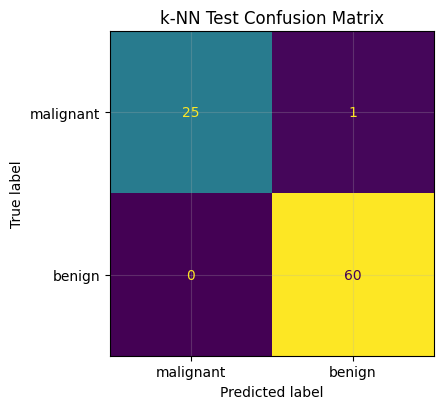

k-NN confusion matrix:
[[25  1]
 [ 0 60]]


In [10]:

# Confusion matrix for final k-NN
knn_cm = confusion_matrix(y_test, y_test_pred_knn)

fig, ax = plt.subplots(figsize=(4.5, 4.2))
ConfusionMatrixDisplay(
    confusion_matrix=knn_cm,
    display_labels=data.target_names
).plot(ax=ax, colorbar=False)

plt.title("k-NN Test Confusion Matrix")
plt.tight_layout()
plt.savefig("knn_confusion_matrix.png", dpi=200)
plt.show()

print("k-NN confusion matrix:")
print(knn_cm)


**k-NN confusion matrix comment:**

The model makes very few mistakes. In this run, it produces one false positive and no false negatives. That means one benign case is predicted as malignant, while all malignant cases are correctly detected. In medical diagnosis, false negatives are usually more critical because missing a malignant tumor can delay treatment.


## 7. Decision Tree Classifier
Following the lecture perspective, a decision tree learns a set of interpretable if-then style rules through recursive splitting. We tune the tree using the validation set.


In [13]:

# Hyperparameter candidates from the homework
max_depth_values = [2, 4, 6, 8, None]
min_samples_split_values = [2, 5, 10]

dt_results = []

for depth in max_depth_values:
    for min_split in min_samples_split_values:
        # Train a decision tree with the given hyperparameters
        dt_model = DecisionTreeClassifier(
            max_depth=depth,
            min_samples_split=min_split,
            random_state=42
        )
        dt_model.fit(X_train, y_train)

        # Evaluate on validation set
        y_val_pred_dt = dt_model.predict(X_val)
        val_acc_dt = accuracy_score(y_val, y_val_pred_dt)

        dt_results.append({
            "max_depth": depth,
            "min_samples_split": min_split,
            "validation_accuracy": val_acc_dt
        })

dt_results_df = pd.DataFrame(dt_results)
display(dt_results_df)


,max_depth,min_samples_split,validation_accuracy
0,2.0,2,0.917647
1,2.0,5,0.917647
2,2.0,10,0.917647
3,4.0,2,0.964706
4,4.0,5,0.941176
5,4.0,10,0.941176
6,6.0,2,0.964706
7,6.0,5,0.952941
8,6.0,10,0.952941
9,8.0,2,0.941176


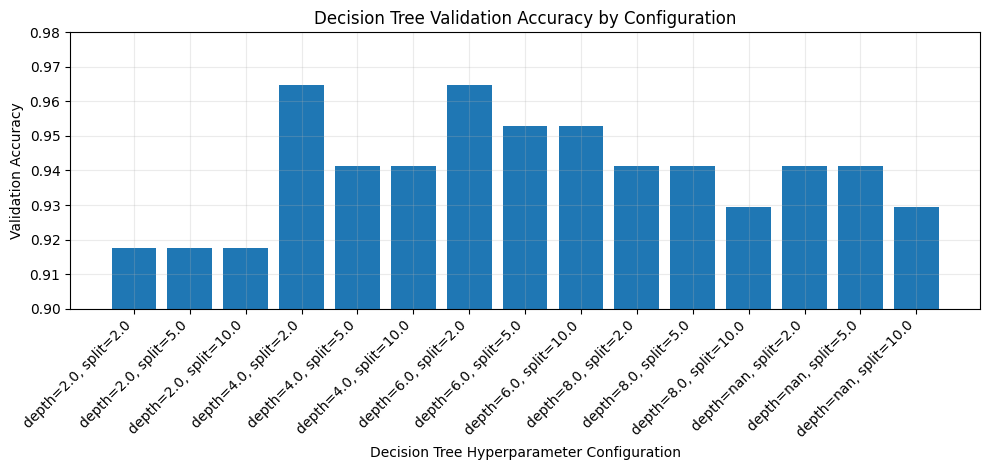

In [14]:

# Plot validation accuracy for each decision tree configuration
config_labels = [
    f"depth={row['max_depth']}, split={row['min_samples_split']}"
    for _, row in dt_results_df.iterrows()
]

plt.figure(figsize=(10, 4.8))
plt.bar(range(len(dt_results_df)), dt_results_df["validation_accuracy"])
plt.xticks(range(len(dt_results_df)), config_labels, rotation=45, ha="right")
plt.xlabel("Decision Tree Hyperparameter Configuration")
plt.ylabel("Validation Accuracy")
plt.title("Decision Tree Validation Accuracy by Configuration")
plt.ylim(0.90, 0.98)
plt.tight_layout()

plt.savefig("dt_validation_accuracy.png", dpi=200)
plt.show()


In [15]:

# Select the best configuration
best_dt_row = dt_results_df.sort_values(
    by=["validation_accuracy", "max_depth", "min_samples_split"],
    ascending=[False, True, True],
    na_position="last"
).iloc[0]

best_depth = best_dt_row["max_depth"]
best_min_split = int(best_dt_row["min_samples_split"])
best_dt_val_acc = best_dt_row["validation_accuracy"]

print("Best decision tree validation accuracy:", round(best_dt_val_acc, 4))
print("Chosen max_depth                    :", best_depth)
print("Chosen min_samples_split            :", best_min_split)


Best decision tree validation accuracy: 0.9647
Chosen max_depth                    : 4.0
Chosen min_samples_split            : 2


### Final Decision Tree Model on Train + Validation
We retrain the best Decision Tree using the combined training and validation data, then evaluate on the test set.


In [16]:

# Train final decision tree on the combined training+validation set
final_dt = DecisionTreeClassifier(
    max_depth=None if pd.isna(best_depth) else int(best_depth),
    min_samples_split=best_min_split,
    random_state=42
)
final_dt.fit(X_train_val, y_train_val)

# Test evaluation
y_test_pred_dt = final_dt.predict(X_test)
dt_test_accuracy = accuracy_score(y_test, y_test_pred_dt)

print(f"Final Decision Tree test accuracy: {dt_test_accuracy:.4f}")


Final Decision Tree test accuracy: 0.9535


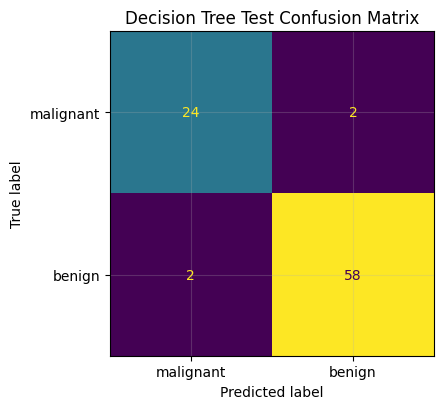

Decision Tree confusion matrix:
[[24  2]
 [ 2 58]]


In [17]:

# Confusion matrix for final decision tree
dt_cm = confusion_matrix(y_test, y_test_pred_dt)

fig, ax = plt.subplots(figsize=(4.5, 4.2))
ConfusionMatrixDisplay(
    confusion_matrix=dt_cm,
    display_labels=data.target_names
).plot(ax=ax, colorbar=False)

plt.title("Decision Tree Test Confusion Matrix")
plt.tight_layout()
plt.savefig("dt_confusion_matrix.png", dpi=200)
plt.show()

print("Decision Tree confusion matrix:")
print(dt_cm)


In [18]:

# Feature importances of the final decision tree
feature_importance_df = pd.DataFrame({
    "Feature": data.feature_names,
    "Importance": final_dt.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("Top 10 feature importances:")
display(feature_importance_df.head(10))


Top 10 feature importances:


,Feature,Importance
7,mean concave points,0.752588
26,worst concavity,0.062596
23,worst area,0.048292
21,worst texture,0.036495
22,worst perimeter,0.032427
29,worst fractal dimension,0.020383
20,worst radius,0.015570
18,symmetry error,0.014013
13,area error,0.012735
27,worst concave points,0.004900


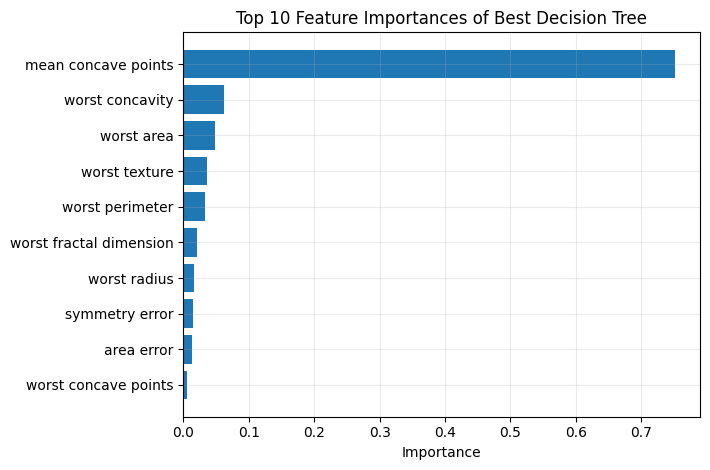

In [19]:

# Plot top 10 feature importances
top_features = feature_importance_df.head(10).sort_values(by="Importance")

plt.figure(figsize=(7.2, 4.8))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances of Best Decision Tree")
plt.tight_layout()

plt.savefig("dt_feature_importances.png", dpi=200)
plt.show()


**Decision Tree comment:**

The most informative feature is **mean concave points**, which receives the highest importance by a large margin. This suggests that the tree relies strongly on shape-related boundary information when separating malignant and benign tumors.


## 8. Misclassification Analysis
- **k-NN:** Only one sample is misclassified on the test set, and it is a benign case predicted as malignant.
- **Decision Tree:** The model makes more errors, including both false positives and false negatives.

In this medical setting, **false negatives** are more critical than false positives because predicting a malignant tumor as benign may delay diagnosis and treatment.


## 9. Conclusion
Both models perform well on this dataset, but **k-NN** achieves higher test accuracy in this homework and makes fewer mistakes on the test set. The **Decision Tree** remains useful because it is more interpretable and provides feature importance information, but its test performance is lower than k-NN in this experiment.
